In [14]:
import pandas as pd
import numpy as np
data={'Hours_Studied':[1,2,3,4,5,6,7],
     'Exam_Score':[50,55,65,70,75,80,85]}
df=pd.DataFrame(data)

x=df[['Hours_Studied']]
# or x=df.iloc[:,0:1]

y=df['Exam_Score']
# or y=df.iloc[:,-1]

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
ypred=lr.predict(x)
diff=pd.DataFrame({'Actual':y,"Predicted":ypred})
diff

,Actual,Predicted
0,50,50.892857
1,55,56.785714
2,65,62.678571
3,70,68.571429
4,75,74.464286
5,80,80.357143
6,85,86.250000


In [15]:
from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y,ypred))
print("MSE: ",metrics.mean_squared_error(y,ypred))
print("R2 score: ",metrics.r2_score(y,ypred))

MAE:  1.2244897959183672
MSE:  1.9132653061224514
R2 square:  0.9864130434782609


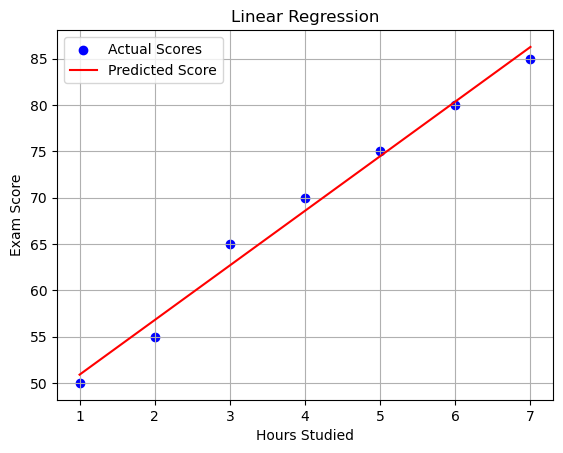

In [19]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color='blue',label='Actual Scores')
plt.plot(x,ypred,color='red',label='Predicted Score')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
data=pd.read_csv("Book1.csv")
df=pd.DataFrame(data)
x=df.iloc[:,0:1]
y=df.iloc[:,-1]
print(x.shape)
print(y.shape)

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
ypred=lr.predict(x_test)

from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y_test,ypred))
print("MSE: ",metrics.mean_squared_error(y_test,ypred))
print("R2 score: ",metrics.r2_score(y_test,ypred))

diff=pd.DataFrame({'Actual Data':y_test,"Predicted Data":ypred})
diff

(200, 1)
(200,)
(160, 1)
(160,)
(40, 1)
(40,)
MAE:  0.29931188593316804
MSE:  0.1370062519255722
R2 score:  0.7283345498058083


,Actual Data,Predicted Data
58,3.09,2.938333
40,4.02,4.368943
34,3.42,3.182584
102,1.37,1.897361
184,3.14,3.496620
198,3.96,3.351233
95,2.79,2.769684
4,3.57,2.949964
29,3.49,3.072090
168,3.52,3.944413


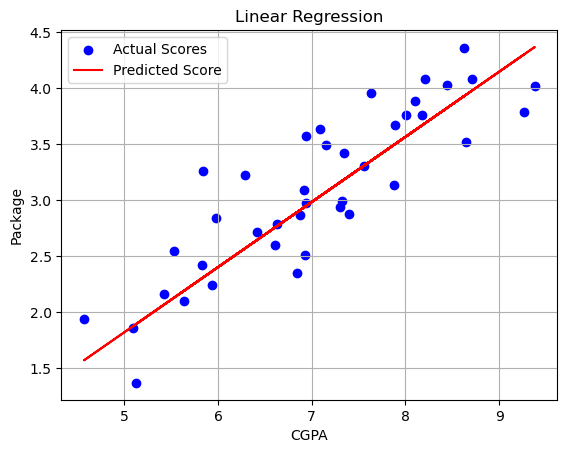

In [28]:
import matplotlib.pyplot as plt
plt.scatter(x_test,y_test,color='blue',label='Actual Scores')
plt.plot(x_test,ypred,color='red',label='Predicted Score')
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
d={}
for i in range(1,43):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=i)
    lr=LinearRegression()
    lr.fit(x_train,y_train)
    ypred=lr.predict(x_test)
    d[i]=metrics.mean_absolute_error(y_test,ypred)
min=d[1]
minstate=1
for i,j in d.items():
    if j<min:
        min=j
        minstate=i
print(min)
print(minstate)

0.18405380979816172
19


<Axes: xlabel='cgpa', ylabel='package'>

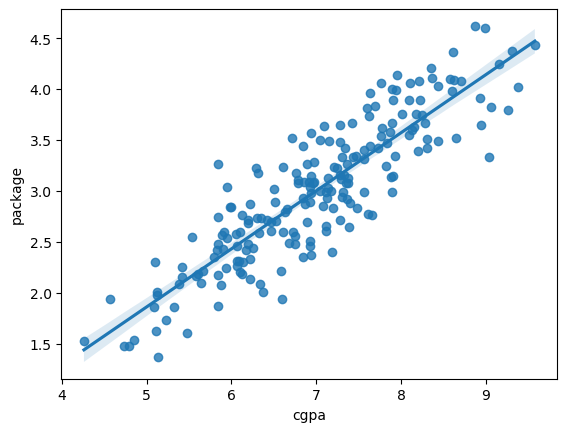

In [37]:
import seaborn as sns
sns.regplot(data=df,x="cgpa",y="package")

In [38]:
ypred=lr.predict([[6.5]])
print(ypred)

[2.70566014]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [46]:
data=pd.read_csv("car data.csv")
df=pd.DataFrame(data)
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [47]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [49]:
df.drop('Car_Name',axis=1,inplace=True)
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [51]:
df['Age']=2026-data['Year']
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [52]:
df.drop('Year',axis=1,inplace=True)
df

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [53]:
df.columns

Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Age'],
      dtype='object')

In [55]:
df=pd.get_dummies(data=df,drop_first=True)
df

,Selling_Price,Present_Price,Kms_Driven,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,0,10,True,False,False,True
297,4.00,5.90,60000,0,11,False,True,False,True
298,3.35,11.00,87934,0,17,False,True,False,True
299,11.50,12.50,9000,0,9,True,False,False,True


In [57]:
y=df["Selling_Price"]
x=df.drop('Selling_Price',axis=1)
# or x=df.iloc[:,1:]
print(x.shape)
print(y.shape)

(301, 8)
(301,)


In [60]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
ypred=lr.predict(x_test)

from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y_test,ypred))
print("MSE: ",metrics.mean_squared_error(y_test,ypred))
print("R2 score: ",metrics.r2_score(y_test,ypred))
print("Coeffient: ",lr.coef_)
print("Intercept: ",lr.intercept_)
diff=pd.DataFrame({'Actual Selling_Price':y_test,"Predicted Selling_Price":ypred})
diff

(240, 8)
(240,)
(61, 8)
(61,)
MAE:  1.0998575552990955
MSE:  2.9823848618597513
R2 score:  0.8625260513315252
Coeffient:  [ 4.37233976e-01 -5.30613944e-06  3.45912849e-01 -4.13270098e-01
  2.23050770e+00  4.58549217e-01 -1.20927814e+00 -1.87014327e+00]
Intercept:  7.900300130264206


,Actual Selling_Price,Predicted Selling_Price
285,7.40,7.862732
248,4.00,2.968287
150,0.50,-0.590305
217,3.15,4.213360
107,1.25,0.483176
...,...,...
62,18.75,20.480622
154,0.50,0.662504
218,6.45,5.400274
286,5.65,5.658562
